# ECE1513 Tutorial 2

### Learning outcomes:
* Brief review of probability
* Gaussian Maximum Likelihood
* Gaussian mixture model (GMM)

## Probability Overview

### Random Variable (RV)
A random variable X is a function:

$X : \Omega \rightarrow \mathbb{R}$

It maps outcomes of a random experiment to real numbers.
___
#### Discrete Random Variable
- Takes values in a finite or countable set
- Defined by a Probability Mass Function (PMF)

PMF:

$p_X(x) = P(X = x)$

Properties:
   * $p_X(x) \geq 0$
   * $\sum_x p_X(x) = 1$
___
#### Continuous Random Variable
- Takes values in a continuous interval
- Defined by a Probability Density Function (PDF)

PMF:

   $P(a \leq X \leq b) = \int_a^b f_X(x) dx$
   
Properties:
   * $f_X(x) \geq 0$
   * $\int_{-\infty}^{\infty} f_X(x) dx = 1$
   * $P(X = x) = 0$ for any single $x$
___

#### Expected Value

Discrete:

   $E[X] = \sum_x x p_X(x)$

Continuous:

   $E[X] = \int_{-\infty}^{\infty} x f_X(x) dx $

For a function $g(X)$:
   * $E[g(X)] = \sum_x g(x) p_X(x)$
   * $E[g(X)] = \infty_x g(x) f_X(x) dx$

___
#### Variance

 Definition:
   $ Var(X) = E[(X - \mu)^2]$,  where $\mu = E[X]$

 Equivalent formula:
   $Var(X) = E[X^2] - (E[X])^2$

 Properties:
   * $Var(X) \geq 0$
   * $Var(aX + b) = a^2 Var(X)$
   * $Var(X) = 0 \iff X$ is constant

___
#### Independance
 Random variables:
 
   $X \perp Y  \iff  P(X, Y ) = P(X )P(Y )$

 Equivalent formulations:
   * Discrete:    $p_{X,Y}(x,y) = p_X(x) p_Y(y)$
   * Continuous:  $f_{X,Y}(x,y) = f_X(x) f_Y(y)$

___
#### Bernoulli RV (Discrete)

Definition:
A Bernoulli RV models a single trial with success probability $p$

Support:

   $X \in {0, 1}$

PMF:
   * $P(X = 1) = p$
   * $P(X = 0) = 1 - p$

Expected value:

   $ E[X] = 0 P(X=0)+1 P(X=1)= P(X=1) = p$

Variance:

   $Var(X) = p(1 - p)$

___
#### Gaussian RV (continuous)

Definition:

   $X\sim \mathcal{N}(\mu, \sigma^2)$

PDF:

   $f_X(x) = \frac{1}{\sigma  \sqrt{2\pi}}  \exp(-(x - \mu)^2 / (2\sigma^2))$

Properties:
   * $E[X] = \mu$
   * $Var(X) = \sigma^2$
___
#### Central Limit Theorem (CLT)
If $X_1,X_2,\cdots,X_N$ are independant and identically distributed (iid) RVs with any distribution, then for large $N$

$\frac{1}{N} \sum_i X_i  \sim \mathcal{N}(\mu,\sigma^2/N)$

where $\mu=E[X_i]$ and $\sigma^2 = Var(X_i)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [2]:
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

In [3]:
data = load_diabetes()
X = data.data  # shape (n_samples, n_features)
feature_names = data.feature_names
print("Feature names:", feature_names)

bmi_idx = feature_names.index('bmi')
bmi = X[:, bmi_idx]
print('Total samples:', bmi.shape[0])


Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Total samples: 442


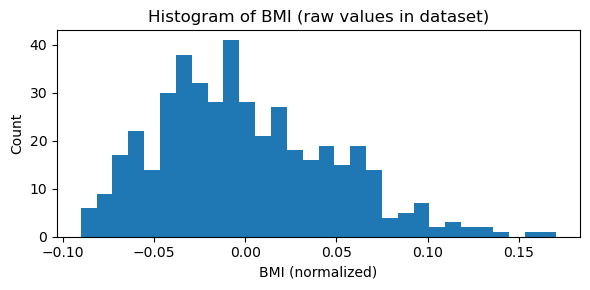

In [4]:
plt.figure(figsize=(6,3))
plt.hist(bmi, bins=30)
plt.title('Histogram of BMI (raw values in dataset)')
plt.xlabel('BMI (normalized)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [5]:
X_train, X_test = train_test_split(bmi, test_size=0.3, random_state=RANDOM_STATE)
print('Train size:', X_train.size, 'Test size:', X_test.size)

Train size: 309 Test size: 133


## Gaussian Model
We will initially consider a simple Gaussian model for the BMI. A Gaussian can be completely characterized by its first and second moments, i.e., by its mean and variance.

In [6]:
def mle_gaussian_parameters(x):
    n = x.size
    mu_hat = x.mean()
    var_hat = ((x - mu_hat) ** 2).mean()  # MLE divisor = n
    return mu_hat, var_hat

mu_mle, var_mle = mle_gaussian_parameters(X_train)
sigma_mle = np.sqrt(var_mle)
print(f"MLE mean: {mu_mle:.6f}, MLE variance: {var_mle:.6f}, sigma: {sigma_mle:.6f}")

MLE mean: -0.001298, MLE variance: 0.002332, sigma: 0.048290


### Maximum Log-Likelihood
For a Gaussian random variable, the (normalized) log-likelihood is:
$$-\frac{1}{2} \log(2\pi) - \frac{1}{2}\log(\sigma^2) - \frac{1}{2 N \sigma^2}\sum_{n=1}^{N} (x_i-\mu)^2$$
It was shown in class that this is maximized when $\mu$ is the mean of the data, $\{x_i\}$, and $\sigma^2$ its variance. We shall show this empirically with our BMI data. We will do this with our traning data

In [8]:
def gaussian_log_likelihood(x, mu, var):
    """Return total log-likelihood for data x under N(mu, var).
    var must be positive (scalar)."""
    n = x.size
    # Use the closed-form expression
    ll = -0.5 *  np.log(2 * np.pi)
    ll += -0.5 *  np.log(var)
    ll += -0.5 * np.sum((x - mu) ** 2) / (var*n)
    return ll

# Quick check: compute log-likelihood at MLE
ll_mle = gaussian_log_likelihood(X_train, mu_mle, var_mle)
print('Train log-likelihood at MLE:', ll_mle)


Train log-likelihood at MLE: 1.611602109399172


Grid maximum at mu= -0.0012982467314372331 , var= 0.00232488246425797


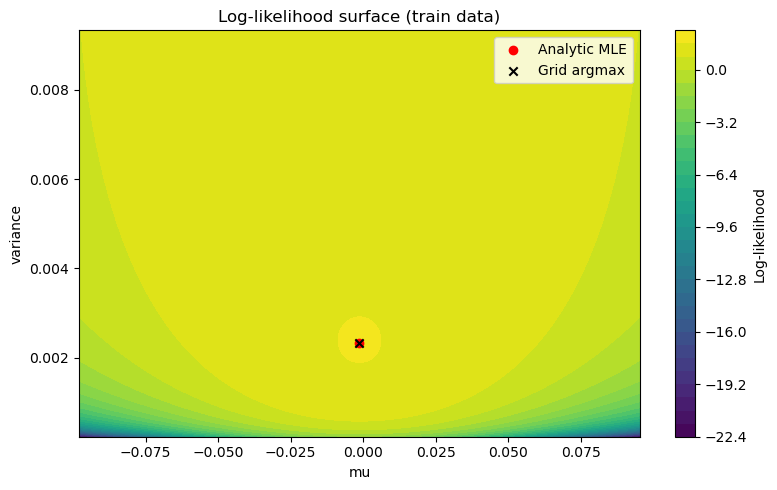

In [9]:
# Construct a reasonable grid around the MLE
train_std = X_train.std(ddof=0)
mu_grid = np.linspace(mu_mle - 2 * train_std, mu_mle + 2 * train_std, 201)
var_grid = np.linspace(max(1e-6, var_mle * 0.1), var_mle * 4.0, 201)  # keep var positive
MU, VAR = np.meshgrid(mu_grid, var_grid)

# Compute log-likelihood on the grid (vectorized along flattened grid)
mu_flat = MU.ravel()
var_flat = VAR.ravel()
LL_flat = np.array([gaussian_log_likelihood(X_train, m, v) for m, v in zip(mu_flat, var_flat)])
LL = LL_flat.reshape(MU.shape)

# Locate maximum in the grid
idx_max = np.unravel_index(np.argmax(LL), LL.shape)
mu_grid_max = MU[idx_max]
var_grid_max = VAR[idx_max]
print('Grid maximum at mu=', mu_grid_max, ', var=', var_grid_max)

# Plot contour (log-likelihood)
plt.figure(figsize=(8,5))
cs = plt.contourf(MU, VAR, LL, levels=30)
plt.colorbar(cs, label='Log-likelihood')
plt.scatter([mu_mle], [var_mle], color='red', label='Analytic MLE', zorder=10)
plt.scatter([mu_grid_max], [var_grid_max], marker='x', color='black', label='Grid argmax', zorder=11)
plt.xlabel('mu')
plt.ylabel('variance')
plt.title('Log-likelihood surface (train data)')
plt.legend()
plt.tight_layout()
plt.show()


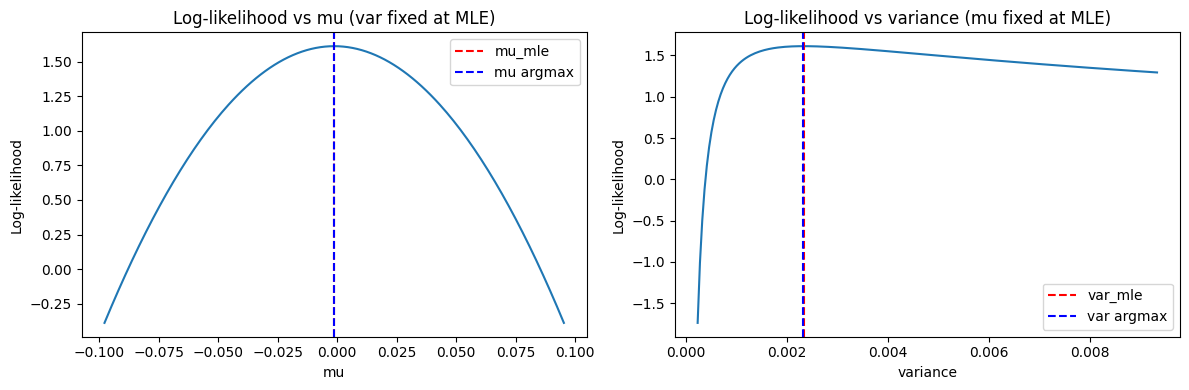

In [9]:

# Plot 1-D slices: log-likelihood vs mu (fixing var at MLE) and vs var (fixing mu at MLE)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
ll_vs_mu = [gaussian_log_likelihood(X_train, m, var_mle) for m in mu_grid]
plt.plot(mu_grid, ll_vs_mu)
plt.axvline(mu_mle, color='red', linestyle='--', label='mu_mle')
plt.axvline(mu_grid_max, color='blue', linestyle='--', label='mu argmax')
plt.title('Log-likelihood vs mu (var fixed at MLE)')
plt.xlabel('mu')
plt.ylabel('Log-likelihood')
plt.legend()

plt.subplot(1,2,2)
ll_vs_var = [gaussian_log_likelihood(X_train, mu_mle, v) for v in var_grid]
plt.plot(var_grid, ll_vs_var)
plt.axvline(var_mle, color='red', linestyle='--', label='var_mle')
plt.axvline(var_grid_max, color='blue', linestyle='--', label='var argmax')
plt.title('Log-likelihood vs variance (mu fixed at MLE)')
plt.xlabel('variance')
plt.ylabel('Log-likelihood')
plt.legend()
plt.tight_layout()
plt.show()



In [10]:
print('Analytic MLE mean:', mu_mle)
print('Grid argmax mean:', mu_grid_max)

print('Analytic MLE variance:', var_mle)
print('Grid argmax variance:', var_grid_max)


Analytic MLE mean: -0.001298246731437237
Grid argmax mean: -0.0012982467314372331
Analytic MLE variance: 0.002331878098553631
Grid argmax variance: 0.00232488246425797


## Log-Likelihood of Alternate Mean and Var

How is the log-likelihood affected by using a different value for $\mu$ and $\sigma^2$?

In [11]:
mu_alt = mu_mle + train_std
var_alt = var_mle * 2.0

ll_test_mle = gaussian_log_likelihood(X_test, mu_mle, var_mle)
ll_test_alt = gaussian_log_likelihood(X_test, mu_alt, var_alt)

print('Test log-likelihood (MLE):', ll_test_mle)
print('Test log-likelihood (Alternative):', ll_test_alt)


Test log-likelihood (MLE): 1.6598789740632
Test log-likelihood (Alternative): 1.333839934015095


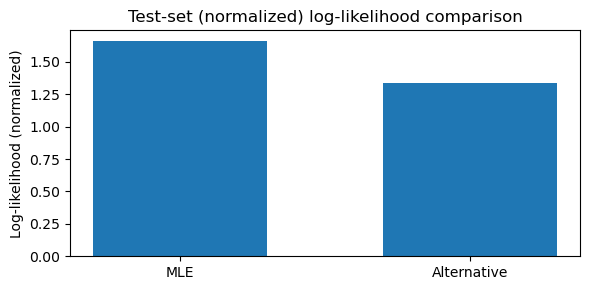

In [12]:
plt.figure(figsize=(6,3))
plt.bar([0,1], [ll_test_mle, ll_test_alt ], width=0.6)
plt.xticks([0,1], ['MLE', 'Alternative'])
plt.ylabel('Log-likelihood (normalized)')
plt.title('Test-set (normalized) log-likelihood comparison')
plt.tight_layout()
plt.show()


## Gaussian Mixture Model
We now consider a Gaussian mixture model instead of just a Guassian. We shall specifically consider a mixture of two Gaussian RVs.

In [13]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(X_train.reshape(-1,1))

# Extract GMM parameters
weights = gmm.weights_.ravel()
means = gmm.means_.ravel()
covs = gmm.covariances_.ravel()  # if full but 1D, this becomes (n_components, 1, 1) or flattened; ensure shape
# If covariances_ has shape (n_comp, 1, 1), flatten correctly
if covs.size != weights.size:
    covs = gmm.covariances_.reshape(gmm.n_components, -1)[:, 0]

print('GMM weights:', weights)
print('GMM means:', means)
print('GMM variances:', covs)


GMM weights: [0.33100907 0.66899093]
GMM means: [ 0.05063034 -0.02699192]
GMM variances: [0.001474   0.00076344]


In [14]:
# Compute test-set average log-likelihood under the GMM via score_samples
ll_test_gmm = gmm.score(X_test.reshape(-1,1))  # score returns average log-likelihood per sample
print('Test log-likelihood (GMM):', ll_test_gmm)


Test log-likelihood (GMM): 1.6419587436579062


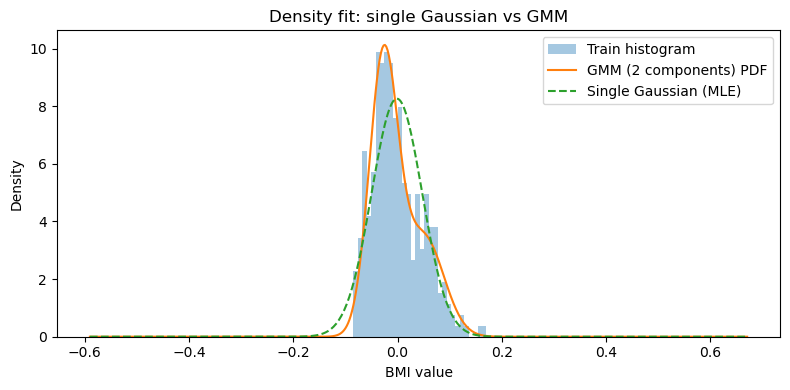

In [15]:
x_grid = np.linspace(bmi.min() - 0.5, bmi.max() + 0.5, 500)
# Compute the GMM PDF on the grid
log_pdf_grid = gmm.score_samples(x_grid.reshape(-1,1))
pdf_grid = np.exp(log_pdf_grid)

# Also compute single-Gaussian PDF from MLE params for comparison
pdf_single = norm.pdf(x_grid, loc=mu_mle, scale=np.sqrt(var_mle))

plt.figure(figsize=(8,4))
plt.hist(X_train, bins=30, density=True, alpha=0.4, label='Train histogram')
plt.plot(x_grid, pdf_grid, label='GMM (2 components) PDF')
plt.plot(x_grid, pdf_single, linestyle='--', label='Single Gaussian (MLE)')
plt.title('Density fit: single Gaussian vs GMM')
plt.xlabel('BMI value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print('--- Test-set (normalized) log-likelihood ---')
print(f'Single Gaussian (MLE): {ll_test_mle:.6f}')
print(f'Single Gaussian (Alternative): {ll_test_alt :.6f}')
print(f'Gaussian Mixture (2 comp): {ll_test_gmm:.6f}')


--- Test-set (normalized) log-likelihood ---
Single Gaussian (MLE): 1.659879
Single Gaussian (Alternative): 1.333840
Gaussian Mixture (2 comp): 1.641959


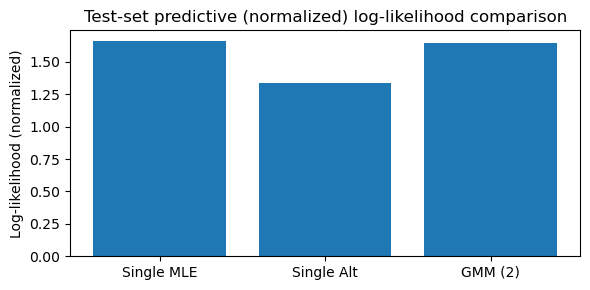

In [17]:
plt.figure(figsize=(6,3))
labels = ['Single MLE', 'Single Alt', 'GMM (2)']
values = [ll_test_mle, ll_test_alt, ll_test_gmm]
plt.bar(labels, values)
plt.ylabel('Log-likelihood (normalized)')
plt.title('Test-set predictive (normalized) log-likelihood comparison')
plt.tight_layout()
plt.show()
